In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris



In [62]:
irisDataset = pd.read_csv("iris.data", 
                          names=["sepallength","sepalwidth",
                                 "petallength","petalwidth","class"])

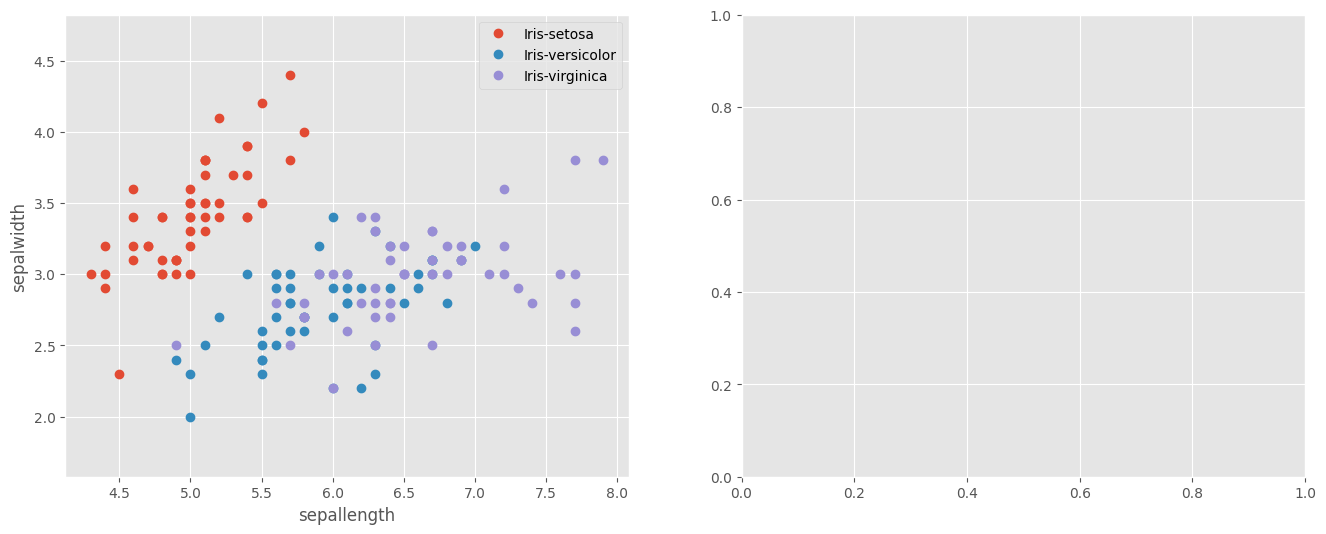

In [63]:
plt.style.use('ggplot')
nomeClases = irisDataset["class"].unique()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for target, target_name in enumerate(nomeClases):
    X_plot = irisDataset[irisDataset["class"] == target_name]
    ax1.plot(X_plot["sepallength"], X_plot["sepalwidth"], 
             linestyle='none', 
             marker='o', 
             label=target_name)
ax1.set_xlabel("sepallength")
ax1.set_ylabel("sepalwidth")
ax1.axis('equal')
ax1.legend()

In [64]:
for target, target_name in enumerate(nomeClases):
    X_plot = irisDataset[irisDataset["class"] == target_name]
    ax2.plot(X_plot["petallength"], X_plot["petalwidth"], 
             linestyle='none', 
             marker='o', 
             label=target_name)
ax2.set_xlabel("petallength")
ax2.set_ylabel("petalwidth")
ax2.axis('equal')
ax2.legend()

In [65]:
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)
    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"


In [66]:
class IrisDataset(Dataset):
  def __init__(self, src_file, root_dir, transform=None):
    irisDataset = pd.read_csv(src_file, names=["sepallength","sepalwidth","petallength","petalwidth","class"])
    X = irisDataset[irisDataset.columns.intersection(["sepallength","sepalwidth","petallength","petalwidth"])]
    Y = irisDataset[irisDataset.columns.intersection(["class"])]
    nomeClases = Y["class"].unique()
    conversion = {v: k for k, v in dict(enumerate(nomeClases)).items()}
    YConversion = pd.DataFrame()
    for nome in nomeClases:
      YConversion[nome] = (Y["class"]==nome).apply(lambda x : 1.0 if x else 0.0)
    y_tensor = torch.as_tensor(YConversion.to_numpy()).type(torch.float32)
    df_dict = dict.fromkeys(X.columns, '')
    X.rename(columns = df_dict)
    s1=X.iloc[:,0:4].values
    x_tensor = torch.tensor(s1)
    scaler = StandardScaler()
    scaler.fit(x_tensor)
    XScalada = scaler.fit_transform(x_tensor).type(torch.float32)
    self.data = torch.cat((XScalada,y_tensor),1)
    self.root_dir = root_dir
    self.transform = transform
  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    if torch.is_tensor(idx):
      idx = idx.tolist()
    preds = self.data[idx, 0:4]
    spcs = self.data[idx, 4:]
    sample = (preds, spcs)
    if self.transform:
      sample = self.transform(sample)
    return sample


In [67]:
dataset = IrisDataset("iris.data",".")
display(dataset[0]) # comprobamos que sae algo

(tensor([-0.8977,  1.0286, -1.3368, -1.3086]), tensor([1., 0., 0.]))

In [68]:
lonxitudeDataset = len(dataset)
tamTrain =int(lonxitudeDataset*0.8)
tamVal = int(lonxitudeDataset*0.2)
print(f"Tam dataset: {lonxitudeDataset} train: {tamTrain} tamVal: {tamVal}")
train_set, val_set = random_split(dataset,[tamTrain,tamVal])
train_ldr = torch.utils.data.DataLoader(train_set, batch_size=2,
    shuffle=True, drop_last=False)
validation_loader =torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)    


Tam dataset: 150 train: 120 tamVal: 30


In [69]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(in_features=50, out_features=3)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.softmax(self.layer3(x), dim=1)
        return x

In [70]:
model     = Model(4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.CrossEntropyLoss()
display(model)

Model(
  (layer1): Linear(in_features=4, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=3, bias=True)
)

In [71]:
entradaProba,dest = next(iter(train_ldr))
print("Entrada:")
display(entradaProba)
print("Desexada:")
display(dest)
saida = model(entradaProba) # esta é a proba de verdade
print("Saída:")
display(saida)
loss_fn(saida, dest)

Entrada:


tensor([[-1.1392, -1.5083, -0.2600, -0.2603],
        [-1.7430, -0.3552, -1.3368, -1.3086]])

Desexada:


tensor([[0., 1., 0.],
        [1., 0., 0.]])

Saída:


tensor([[0.4042, 0.2757, 0.3200],
        [0.4179, 0.2565, 0.3255]], grad_fn=<SoftmaxBackward0>)

tensor(1.0869, grad_fn=<DivBackward1>)

In [72]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    # usamos enumerate para saber en que batch imos
    for i, data in enumerate(train_ldr):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

In [73]:
EPOCHS = 100
loss_list     = torch.zeros((EPOCHS,))
accuracy_list = torch.zeros((EPOCHS,))
writer = SummaryWriter('runs/pruebairis')
for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # Poñemos o modelo en modo entrenamento
    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss
    # Non se precisan os gradientes para o test
    model.train(False)

EPOCH 1:
  batch 10 loss: 1.0947210311889648
  batch 20 loss: 1.0478380918502808
  batch 30 loss: 1.0389341950416564
  batch 40 loss: 0.9886143863201141
  batch 50 loss: 0.9132800340652466
  batch 60 loss: 0.9077540159225463
EPOCH 2:
  batch 10 loss: 0.8533924221992493
  batch 20 loss: 0.8195007741451263
  batch 30 loss: 0.8345487356185913
  batch 40 loss: 0.819746220111847
  batch 50 loss: 0.7914054870605469
  batch 60 loss: 0.8136049985885621
EPOCH 3:
  batch 10 loss: 0.7555974006652832
  batch 20 loss: 0.808742493391037
  batch 30 loss: 0.7548711895942688
  batch 40 loss: 0.6679977238178253
  batch 50 loss: 0.7070050776004791
  batch 60 loss: 0.7432185590267182
EPOCH 4:
  batch 10 loss: 0.678808617591858
  batch 20 loss: 0.7557103574275971
  batch 30 loss: 0.6906287491321563
  batch 40 loss: 0.7093883395195008
  batch 50 loss: 0.6197194397449494
  batch 60 loss: 0.6953208088874817
EPOCH 5:
  batch 10 loss: 0.6944611370563507
  batch 20 loss: 0.6740690052509308
  batch 30 loss: 0.628

In [74]:
running_vloss = 0.0
for i, vdata in enumerate(validation_loader):
    vinputs, vlabels = vdata
    voutputs = model(vinputs)
    vloss = loss_fn(voutputs, vlabels)

    correct = (torch.argmax(voutputs, dim=0) == vlabels).type(torch.FloatTensor)
    accuracy_list[epoch] += correct.sum()
    running_vloss += vloss

avg_vloss = running_vloss / (i + 1)
print('LOSS train {} valid {} {}/{}'.format(avg_loss, avg_vloss,accuracy_list[epoch],int(lonxitudeDataset*0.2)))

LOSS train 0.5516779601573945 valid 0.5516744256019592 26.0/30


Text(0.5, 0, 'epochs')

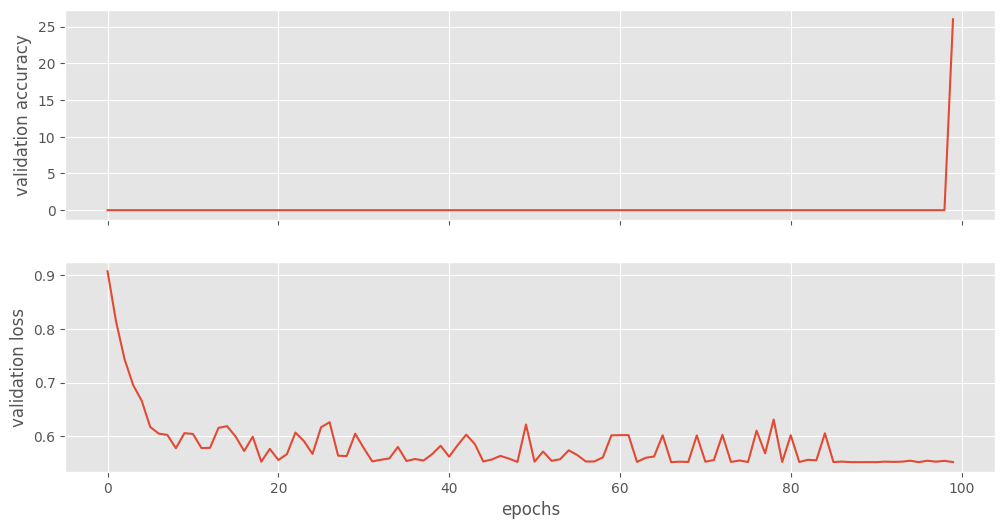

In [75]:
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 6), sharex=True)

ax1.plot(accuracy_list)
ax1.set_ylabel("validation accuracy")
ax2.plot(loss_list)
ax2.set_ylabel("validation loss")
ax2.set_xlabel("epochs")

In [76]:
mappings = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}
data = irisDataset.copy()
data['class'] = data['class'].map(mappings)

X_numpy = data.iloc[:, 0:4].values
y_numpy = data['class'].values

X = torch.tensor(X_numpy, dtype=torch.float32)
y = torch.tensor(y_numpy, dtype=torch.long)

In [77]:
class IrisData(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instanciamos tu dataset
dataset = IrisData(X, y)

# Dividir: 80% entrenamiento, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = random_split(dataset, [train_size, test_size])

# Preparar los cargadores para el bucle
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

In [78]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 4 entradas (largo/ancho sépalo y pétalo) -> 10 neuronas
        self.fc1 = nn.Linear(4, 10)
        self.fc2 = nn.Linear(10, 10)
        # 3 salidas (setosa, versicolor, virginica)
        self.output = nn.Linear(10, 3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.output(x)
        return x

model = Net()

Época 10: Error = 0.1558
Época 20: Error = 0.1598
Época 30: Error = 0.0875
Época 40: Error = 0.0700
Época 50: Error = 0.0787
Época 60: Error = 0.0628
Época 70: Error = 0.0762
Época 80: Error = 0.0909
Época 90: Error = 0.0850
Época 100: Error = 0.0639


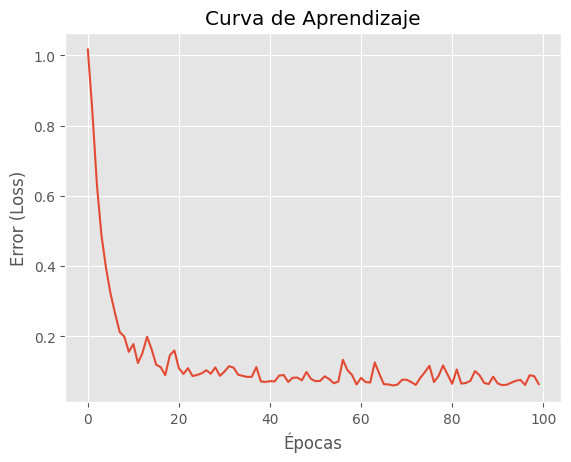

In [79]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 100
loss_list = []

for epoch in range(epochs):
    model.train() # Modo entrenamiento
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()       # Borrar memoria de gradientes
        outputs = model(inputs)     # Calcular salida
        loss = criterion(outputs, labels) # Calcular error
        loss.backward()             # Calcular mejora (backprop)
        optimizer.step()            # Aplicar mejora
        
        running_loss += loss.item()
    
    # Guardamos el error medio de esta época
    avg_loss = running_loss / len(train_loader)
    loss_list.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f'Época {epoch+1}: Error = {avg_loss:.4f}')

# Visualizar el resultado con matplotlib (que ya tienes importado como plt)
plt.plot(loss_list)
plt.title("Curva de Aprendizaje")
plt.xlabel("Épocas")
plt.ylabel("Error (Loss)")
plt.show()

In [80]:
model.eval() # Modo evaluación
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Precisión del modelo en el set de prueba: {100 * correct / total:.2f}%')

Precisión del modelo en el set de prueba: 100.00%
